In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('default')
import datetime

from matplotlib import cm
import matplotlib.colors
import seaborn as sns
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from scipy.spatial.distance import pdist, squareform
from sklearn.linear_model import ElasticNet
from sklearn.datasets import make_regression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

In [3]:
d_today = datetime.date.today()

fig_data_path = f"result/figure/{d_today}/"
fig_data_path

'result/figure/2024-09-25/'

In [7]:
d_today = datetime.date.today()
folder_path = "/Users/ayo/Desktop/_GSAIS_/mzmtlab/microbiome dynamics"
## plot save path
fig_data_path = f"{folder_path}/result/FluSub_JP/{d_today}/figure/"


In [8]:
fig_data_path

'/Users/ayo/Desktop/_GSAIS_/mzmtlab/microbiome dynamics/result/FluSub_JP/2024-09-25/figure/'

In [9]:
data = pd.read_csv(
    f"{folder_path}/data/FluSub_jp/FluSub_11to19_jp_per_20240925.csv")
data

,date,year,week,TimeALL,TimeYearCode,TimePerYear,flu_Japan,A,A_H1N1,A_H3N2,B,B_Victoria,B_Yamagata,B_unknown
0,40791,2011,36,1,2011,1,58,58.0,0.0,58.0,0.0,0.0,0.0,0.0
1,40798,2011,37,2,2011,2,91,11.6,0.0,11.6,0.0,0.0,0.0,0.0
2,40805,2011,38,3,2011,3,101,23.2,0.0,23.2,0.0,0.0,0.0,0.0
3,40812,2011,39,4,2011,4,185,69.6,0.0,69.6,11.6,0.0,11.6,0.0
4,40819,2011,40,5,2011,5,306,58.0,0.0,58.0,58.0,58.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
411,43675,2019,31,412,2018,48,947,174.0,162.4,11.6,23.2,23.2,0.0,0.0
412,43682,2019,32,413,2018,49,1025,116.0,104.4,11.6,23.2,23.2,0.0,0.0
413,43689,2019,33,414,2018,50,1075,58.0,58.0,0.0,34.8,34.8,0.0,0.0
414,43696,2019,34,415,2018,51,1157,150.8,139.2,11.6,58.0,58.0,0.0,0.0


In [10]:
data[data["TimeYearCode"] == 2011]["A"]

0        58.0
1        11.6
2        23.2
3        69.6
4        58.0
5       220.4
6       208.8
7       255.2
8       301.6
9        81.2
10      533.6
11      510.4
12      881.6
13     1357.2
14     1821.2
15     1960.4
16     1241.2
17     1844.4
18     4814.0
19    10068.8
20     7134.0
21     6368.4
22     4779.2
23     4036.8
24     3143.6
25     1983.6
26     1496.4
27      928.0
28      591.6
29      371.2
30      440.8
31      417.6
32      208.8
33      208.8
34       34.8
35       46.4
36      150.8
37       23.2
38       34.8
39       23.2
40       11.6
41       23.2
42      208.8
43       58.0
44      139.2
45       34.8
46       92.8
47      104.4
48      185.6
49       69.6
50       58.0
51      127.6
Name: A, dtype: float64

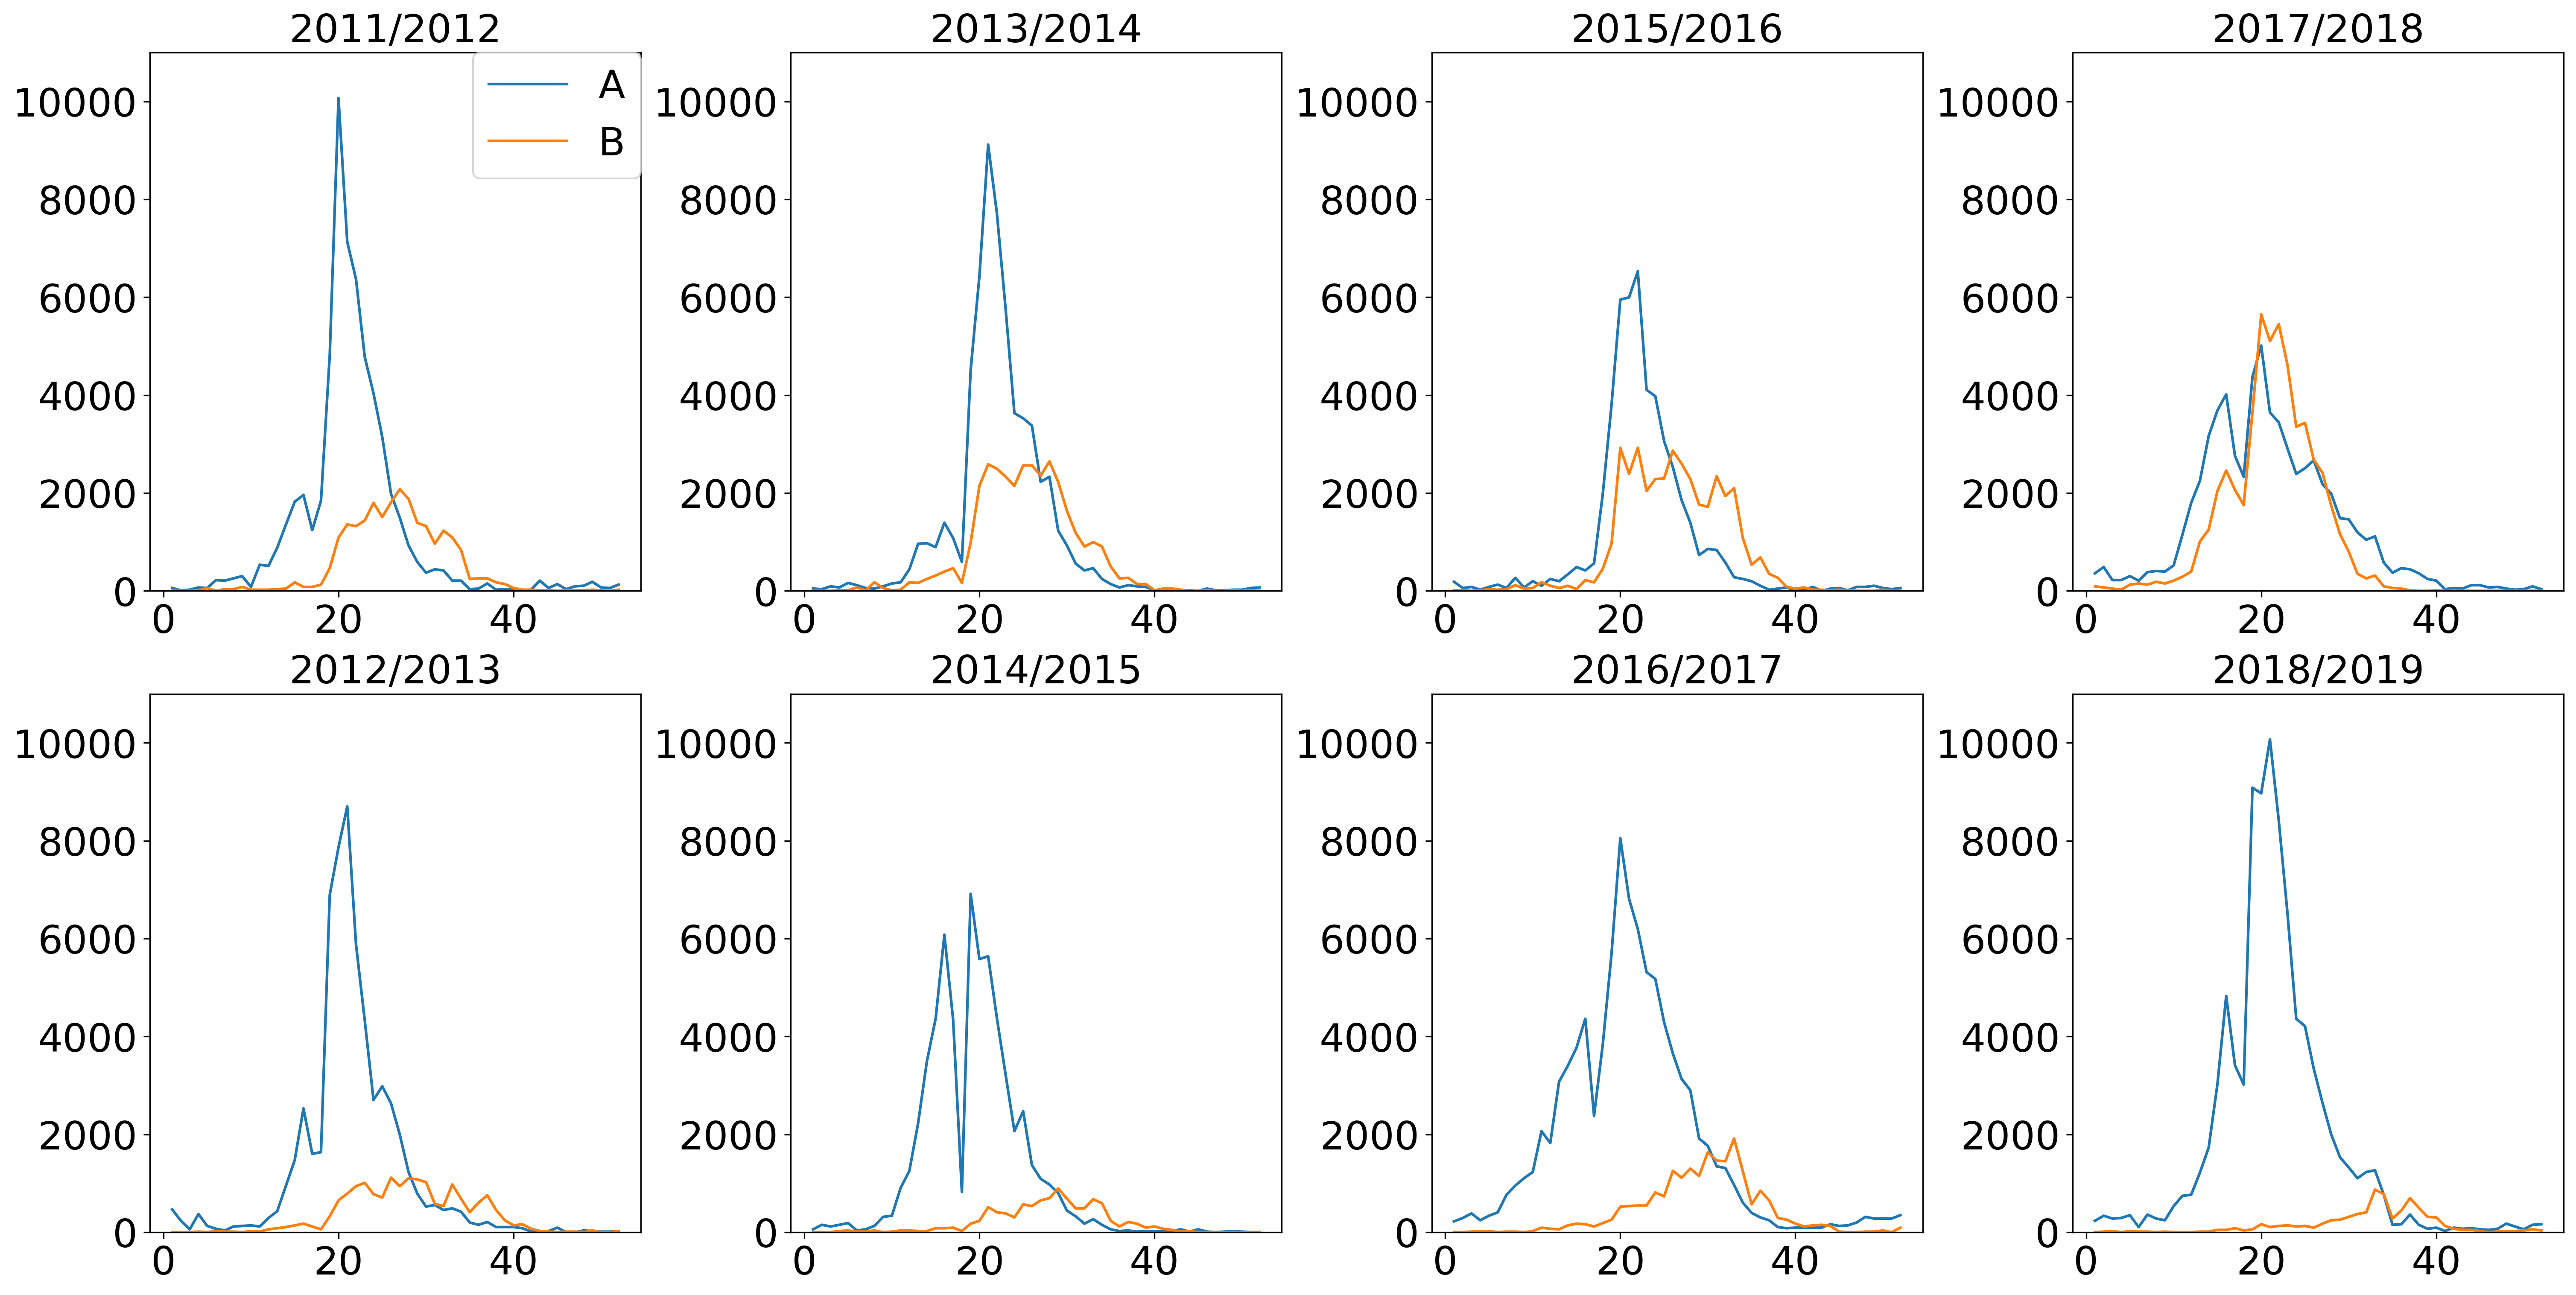

In [19]:
fig, axs = plt.subplots(2, 4, figsize=(20, 10), dpi=300, layout='constrained')

for i in range(8):
    font_size = 22
    row = i % 2
    col = i // 2
    year = 2011 + i
    # print(year)
    axs[row, col].plot(data[data["TimeYearCode"] == year]["TimePerYear"],
                       data[data["TimeYearCode"] == year]["A"],
                       label="A")
    axs[row, col].plot(data[data["TimeYearCode"] == year]["TimePerYear"],
                       data[data["TimeYearCode"] == year]["B"],
                       label="B")
    axs[row, col].set_ylim(0, 11000)
    axs[row, col].set_title(f'{year}/{year + 1}', fontsize=font_size)
    axs[row, col].tick_params(labelsize=font_size)
axs[0, 0].legend(bbox_to_anchor=(1, 1), loc='upper right', borderaxespad=0, fontsize=font_size)
plt.savefig(f"{fig_data_path}ts/Flu_A_B.tiff", format="tiff", pil_kwargs={"compression": "tiff_lzw"})
plt.show()

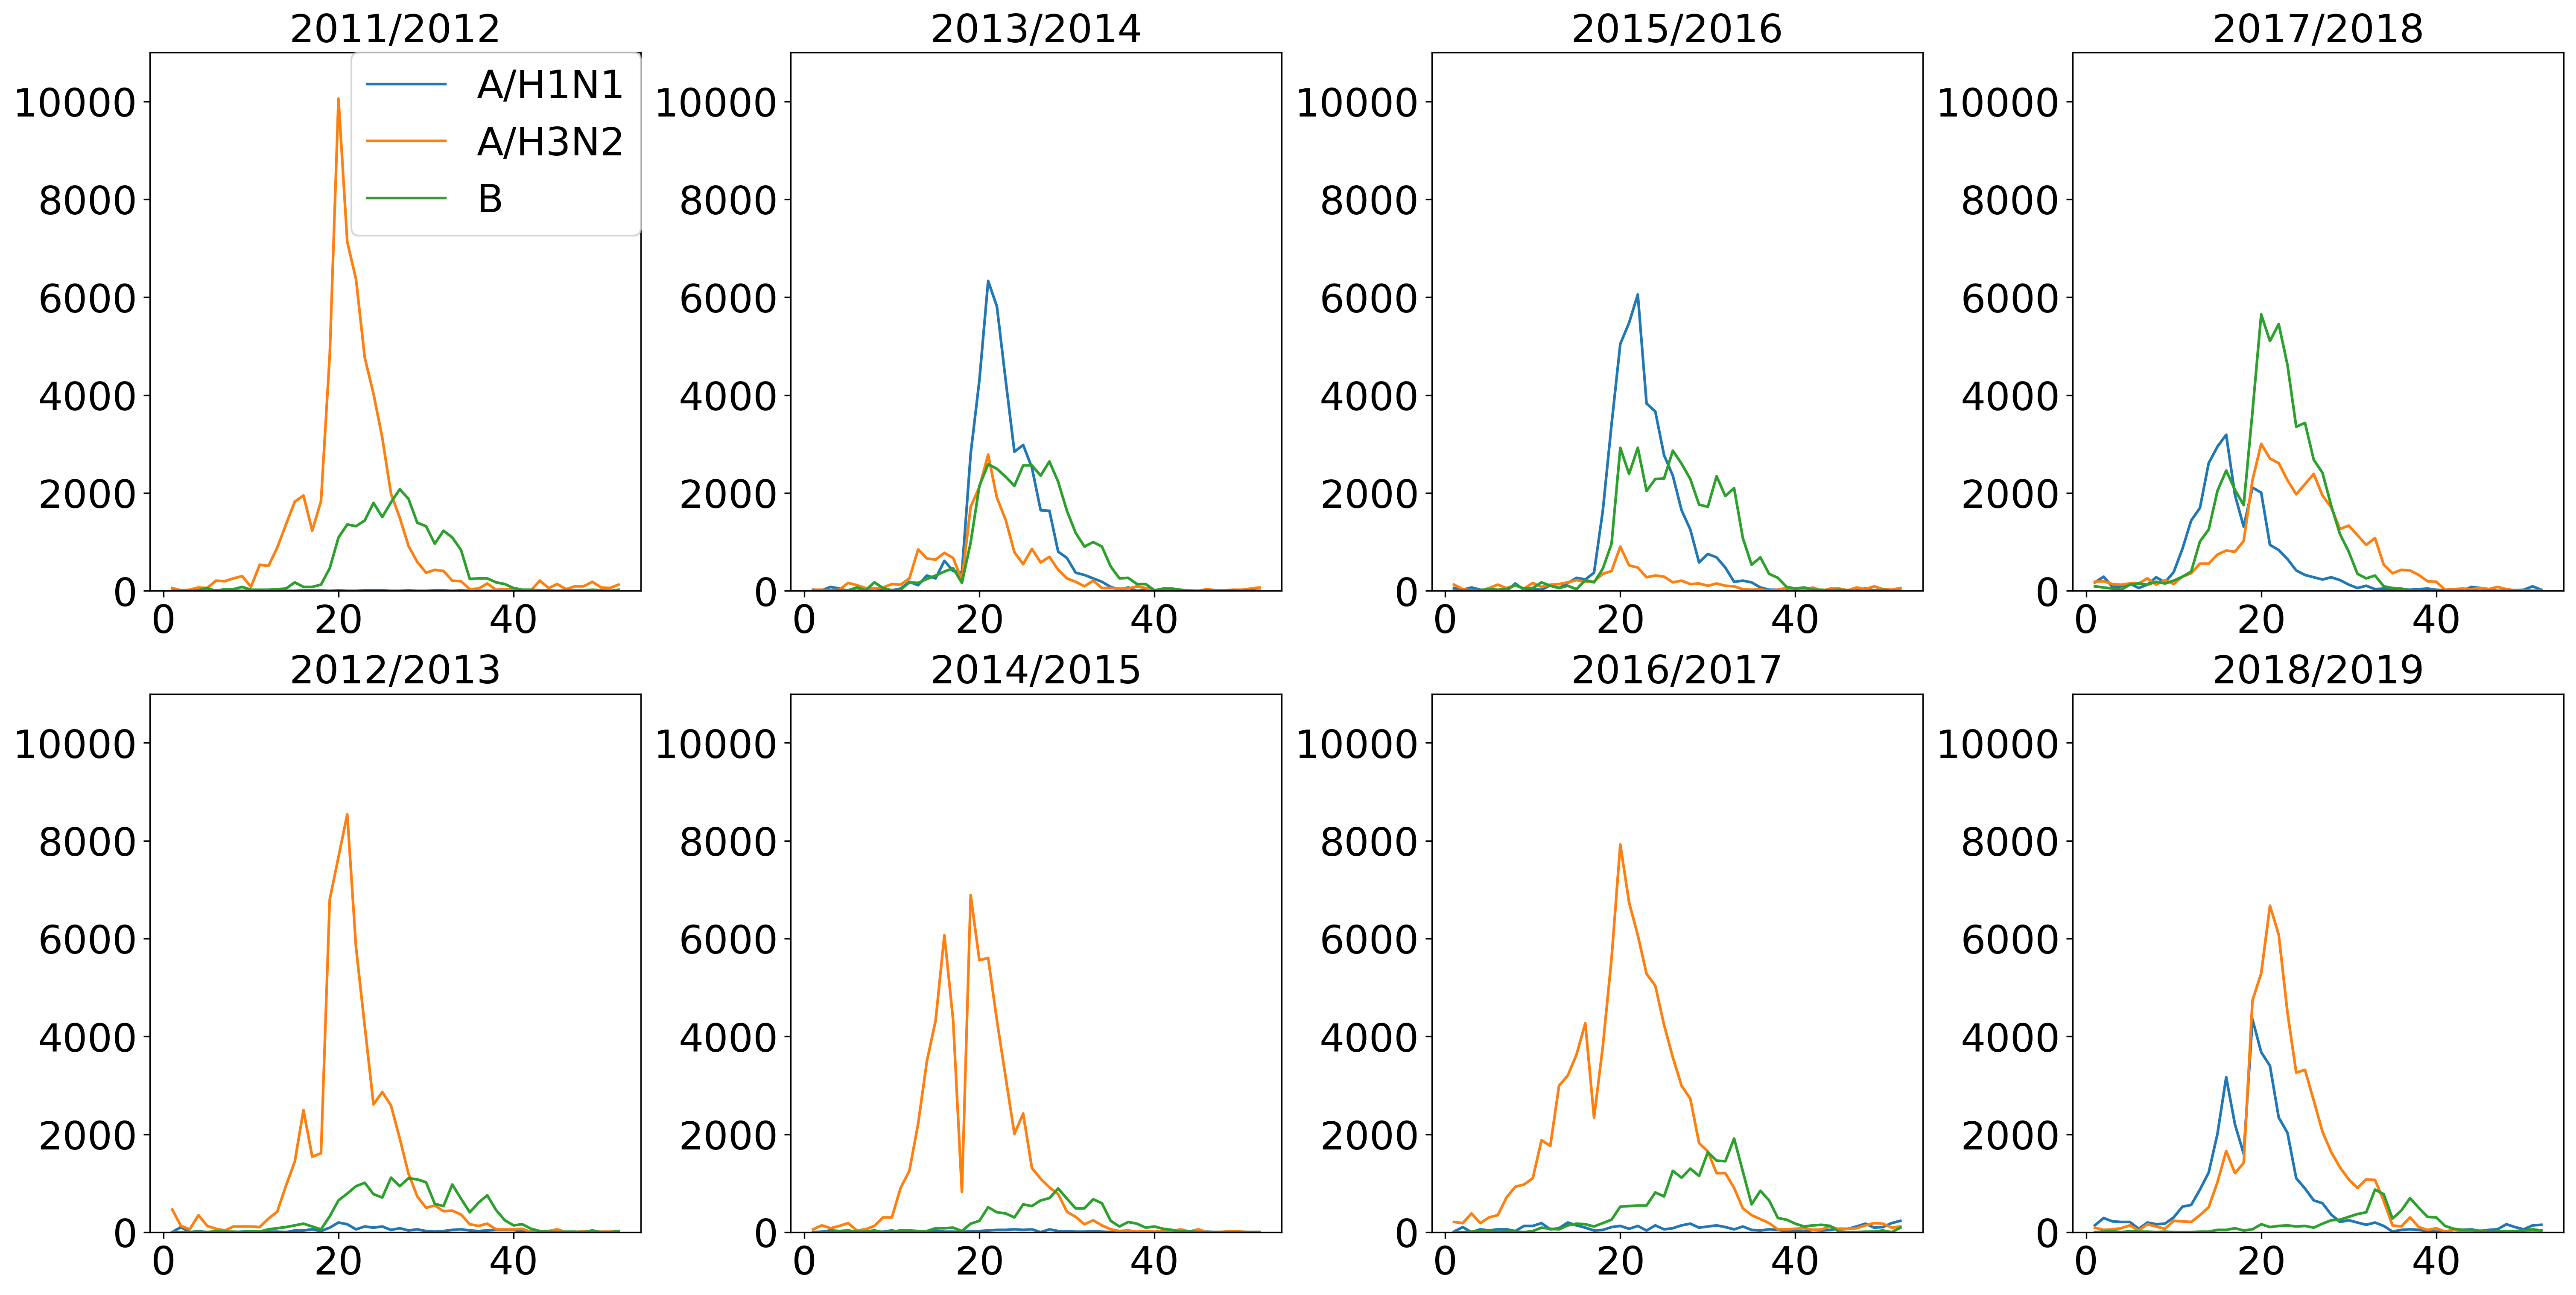

In [22]:
data[data["TimeYearCode"] == 2011]["A"]
fig, axs = plt.subplots(2, 4, figsize=(20, 10), dpi=300, layout='constrained')

for i in range(8):
    font_size = 22
    row = i % 2
    col = i // 2
    year = 2011 + i
    # print(year)
    axs[row, col].plot(data[data["TimeYearCode"] == year]["TimePerYear"],
                       data[data["TimeYearCode"] == year]["A_H1N1"],
                       label="A/H1N1")
    axs[row, col].plot(data[data["TimeYearCode"] == year]["TimePerYear"],
                       data[data["TimeYearCode"] == year]["A_H3N2"],
                       label="A/H3N2")
    axs[row, col].plot(data[data["TimeYearCode"] == year]["TimePerYear"],
                       data[data["TimeYearCode"] == year]["B"],
                       label="B")
    axs[row, col].set_ylim(0, 11000)
    axs[row, col].set_title(f'{year}/{year + 1}', fontsize=font_size)
    axs[row, col].tick_params(labelsize=font_size)
axs[0, 0].legend(bbox_to_anchor=(1, 1), loc='upper right', borderaxespad=0, fontsize=font_size)
plt.savefig(f"{fig_data_path}ts/Flu_AH1_AH3_B.tiff", format="tiff", pil_kwargs={"compression": "tiff_lzw"})
plt.show()